# Notebook 3. Self-Distillation: DINO on UCR Time Series

![Status](https://img.shields.io/static/v1.svg?label=Status&message=Finished&color=green)

**Filled notebook:**
[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lstival/ssl_tutorial_sibgrapi2026/blob/main/notebooks/time_series/03_distillation_dino.ipynb)
**Pretrained checkpoints:**
[![GitHub Releases](https://img.shields.io/static/v1.svg?logo=github&label=Repo&message=Checkpoints&color=lightgrey)](https://github.com/lstival/ssl_tutorial_sibgrapi2026/releases)

**Tutorial:** SIBGRAPI 2026 -- *Self-Supervised Learning: Contrastive, Masking, and Distillation Methods*
**Segment:** 3.4 -- Self-distillation (time series) - Instantiates the lecture part, Section 1.6

---

**Mechanism: self-distillation.** A *student* network is trained to match the output
distribution of a *teacher* -- and the teacher is just an exponential moving average of the
student. No labels, no negatives, no reconstruction. The only signal is agreement between two
views of the same series, through a deliberately slow-moving copy of the model itself.

This is DINO (Caron et al., 2021). The obvious objection is that it should collapse: if the
student can output the same vector for every input, the loss is trivially minimized. Two
ingredients prevent that:

- **Centering**: subtract a running mean of teacher outputs, which stops any single dimension
  from dominating.
- **Sharpening**: a low teacher temperature ($\tau_t = 0.04$ vs. student $\tau_s = 0.1$),
  which keeps the teacher's target distribution peaked.

Centering pushes toward uniform, sharpening pushes toward peaked; collapse is the failure of
that balance, and we will watch it directly via the teacher's output entropy.

### The loss

$$
\mathcal{L} = -\sum_{\text{view pairs}} P_t(x_i)^\top \log P_s(x_j), \qquad
P_t = \text{softmax}\!\left(\frac{g_t(x) - c}{\tau_t}\right),\;
P_s = \text{softmax}\!\left(\frac{g_s(x)}{\tau_s}\right)
$$

In [1]:
## Standard libraries
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
from copy import deepcopy

## Imports for plotting
import matplotlib.pyplot as plt
import numpy as np

## tqdm for loading bars
from tqdm.auto import tqdm

## PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim

%matplotlib inline

c:\Users\stiva\anaconda3\envs\bepe\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Make the shared tutorial module importable.
import os, sys, urllib.request

_LOCAL_SRC = os.path.join("..", "..", "src", "time_series")
if os.path.isfile(os.path.join(_LOCAL_SRC, "tutorial_ts.py")):
    sys.path.insert(0, _LOCAL_SRC)
elif not os.path.isfile("tutorial_ts.py"):
    urllib.request.urlretrieve("https://raw.githubusercontent.com/lstival/ssl_tutorial_sibgrapi2026/main/src/time_series/tutorial_ts.py", "tutorial_ts.py")

from tutorial_ts import (
    seed_everything, get_device, setup_plotting, check_colab_gpu, stage_ucr_locally,
    TARGET_DATASET, SERIES_LEN, PATCH_LEN, PATCH_STRIDE,
    UCRDataset, UCRCorpusDataset, ucr_class_names,
    MultiCropTransform, build_ts_augmentations, build_ts_local_augmentations,
    build_ts_encoder, try_load_checkpoint,
    plot_curve, overlay_attention_1d,
    extract_features, linear_probe_accuracy, plot_embedding_scatter,
)

setup_plotting()
seed_everything(42)
device = get_device()
print("Device:", device)
check_colab_gpu(device)

DATA_PATH = "../../data"
CHECKPOINT_PATH = "../../artifacts/time_series/checkpoints"

# On Colab, each notebook opened via File > Open notebook > GitHub gets its own fresh VM: a
# checkpoint saved -- or dataset downloaded -- by this notebook is invisible to another
# notebook opened separately, only to cells further down in *this* notebook. Mounting Drive
# repoints both paths at a folder that survives across notebooks and across sessions, so e.g.
# a checkpoint trained live here is still there when 04_comparative_evaluation runs later, and
# the dataset download only happens once across the whole tutorial. The dataset itself is
# read from the VM's local disk (Drive only keeps its zip): reading thousands of small files
# through the Drive mount is slow enough to starve the GPU.
# Flip USE_DRIVE_FOR_TUTORIAL_DATA to False to keep everything local to this VM instead (e.g.
# to skip the Drive permission prompt, at the cost of losing state between notebooks).
USE_DRIVE_FOR_TUTORIAL_DATA = True
if USE_DRIVE_FOR_TUTORIAL_DATA and "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")
    _drive_root = "/content/drive/MyDrive/ssl_tutorial_sibgrapi2026/time_series"
    CHECKPOINT_PATH = _drive_root + "/checkpoints"
    DATA_PATH = stage_ucr_locally("/content/data", _drive_root + "/data")
    os.makedirs(CHECKPOINT_PATH, exist_ok=True)
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

# Colab (Linux) can run the augmentations in background worker processes, which keeps the GPU
# fed; local runs keep the single-process loading the notebooks were tuned with.
NUM_WORKERS = min(4, os.cpu_count() or 1) if "google.colab" in sys.modules else 0

Device: cuda:0


<Figure size 640x480 with 0 Axes>

In [ ]:
# --- Check that the pretrained encoders are reachable -------------------------------
# Weights are published on a GitHub Release. Locally they are already on disk once fetched; on Colab they
# are downloaded on demand. This cell just reports what is available, so a missing or
# mis-served checkpoint shows up here rather than halfway through training below.
import os, urllib.request, urllib.error

_CKPTS = ["contrastive_ts_encoder.pt", "mae_ts_encoder.pt", "dino_ts_encoder.pt"]
_REPO = "lstival/ssl_tutorial_sibgrapi2026"
_MEDIA = f"https://github.com/{_REPO}/releases/download/weights-v1/"

for _name in _CKPTS:
    _local = os.path.join(CHECKPOINT_PATH, _name)
    _repo_copy = os.path.join("..", "..", "artifacts", "time_series", "checkpoints", _name)
    _found = next((p for p in (_local, _repo_copy) if os.path.isfile(p)), None)
    if _found and os.path.getsize(_found) > 1024:
        print(f"  on disk    {_name:<26} {os.path.getsize(_found)/1048576:.1f} MB")
        continue
    try:
        _req = urllib.request.Request(_MEDIA + _name, method="HEAD")
        with urllib.request.urlopen(_req, timeout=20) as _r:
            _mb = int(_r.headers.get("Content-Length") or 0) / 1048576
        print(f"  downloadable {_name:<24} {_mb:.1f} MB")
    except Exception as _e:
        print(f"  UNAVAILABLE  {_name:<24} {_e} -> this notebook will train live instead")


## Multi-crop: several views per series

DINO's other key ingredient is **multi-crop**: 2 *global* views (mild augmentation, most of the
series) and 4 *local* views (a short sub-interval, stretched back to full length). The teacher
sees only the global views; the student sees all six.

That asymmetry creates the learning signal: the student must predict what the teacher computes
from the *whole* series while itself seeing only a fragment. It is forced to infer global
identity from local evidence -- for a leaf outline, to recognize the species from a few lobes.

In [3]:
multicrop = MultiCropTransform(
    build_ts_augmentations(), build_ts_local_augmentations(), n_global=2, n_local=4,
)
train_corpus = UCRCorpusDataset(DATA_PATH, per_dataset_cap=2000, transform=multicrop)


def multicrop_collate(batch):
    """Each sample is a list of crops -> return a list of batched crop tensors."""
    n_crops = len(batch[0])
    return [torch.stack([sample[i] for sample in batch], dim=0) for i in range(n_crops)]


train_loader = data.DataLoader(train_corpus, batch_size=128, shuffle=True, drop_last=True,
                               num_workers=NUM_WORKERS, pin_memory=True, collate_fn=multicrop_collate)
print(f"\nDINO training pool: {len(train_corpus)} series x 6 crops each")

UCR pretraining corpus: 45192 series from 128 datasets

DINO training pool: 45192 series x 6 crops each


## Model: student/teacher with a DINO head

Both student and teacher are `encoder + DINOHead` (a 3-layer MLP projecting to a
high-dimensional output space -- 1024 "prototypes" here). The teacher starts as an exact copy of
the student and is **never** updated by gradients: only by EMA.

In [4]:
class DINOHead(nn.Module):
    def __init__(self, embed_dim=128, hidden_dim=256, out_dim=1024):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.mlp(x)


class DINOTSModel(nn.Module):
    def __init__(self, encoder, embed_dim=128, hidden_dim=256, out_dim=1024):
        super().__init__()
        self.encoder = encoder
        self.head = DINOHead(embed_dim, hidden_dim, out_dim)

    def forward(self, x):
        h = self.encoder.forward_features(x, pool="cls")
        return self.head(h)


student = DINOTSModel(build_ts_encoder()).to(device)
teacher = deepcopy(student).to(device)
for p in teacher.parameters():
    p.requires_grad = False

out_dim = student.head.mlp[-1].out_features
center = torch.zeros(1, out_dim, device=device)
print(f"student/teacher built; DINO head output dim = {out_dim}")

student/teacher built; DINO head output dim = 1024


## EMA teacher update

The cell below applies the exponential moving average that is the teacher's *only* form of
learning:

$$\theta_t \leftarrow m\,\theta_t + (1-m)\,\theta_s$$

<div class="alert alert-info">

**Note:** the update iterates `zip(student.parameters(), teacher.parameters())` and writes in
place with `.mul_(m).add_(..., alpha=1-m)` under `@torch.no_grad()`, so no gradients ever
reach the teacher. With $m = 0.996$ the teacher moves ~250x slower than the student -- slow
enough to be a stable target, fast enough to keep up. This is the *same* cell as the remote sensing part's
Notebook 3.

</div>

In [5]:
@torch.no_grad()
def ema_update(student, teacher, m):
    '''In-place EMA: teacher_param <- m * teacher_param + (1-m) * student_param.'''
    for student_param, teacher_param in zip(student.parameters(), teacher.parameters()):
        teacher_param.data.mul_(m).add_(student_param.data, alpha=1 - m)


_s = nn.Linear(4, 4); _t = nn.Linear(4, 4)
ema_update(_s, _t, m=0.0)
print("m=0 -> teacher matches student:", torch.allclose(_s.weight, _t.weight))
_s2 = nn.Linear(4, 4); _t2 = deepcopy(_s2)
old = _t2.weight.clone()
with torch.no_grad():
    _s2.weight += 1.0
ema_update(_s2, _t2, m=1.0)
print("m=1 -> teacher unchanged:", torch.allclose(_t2.weight, old))

m=0 -> teacher matches student: True
m=1 -> teacher unchanged: True


## The DINO loss

The cell below computes the cross-entropy between the teacher's centered, sharply-sharpened
distribution and the student's distribution, summed over all view pairs where student view !=
teacher view.

<div class="alert alert-info">

**Note:** the student side is `F.log_softmax(s / tau_student)` and the teacher side is
`F.softmax((t - center) / tau_teacher).detach()`, so the centering and the sharper teacher
temperature are what keep the two distributions from collapsing onto each other. Pairs where
the indices match are skipped, `-(t_probs * s_log_probs).sum(-1).mean()` is accumulated, and
the total is divided by the number of terms.

</div>

In [6]:
def dino_loss(student_logits_list, teacher_logits_list, center, tau_student=0.1, tau_teacher=0.04):
    '''
    student_logits_list: list of (B, out_dim), one per student view (all crops)
    teacher_logits_list: list of (B, out_dim), one per teacher view (global crops only)
    center: (1, out_dim) running center of teacher outputs
    '''
    student_log_probs = [F.log_softmax(s / tau_student, dim=-1) for s in student_logits_list]
    teacher_probs = [F.softmax((t - center) / tau_teacher, dim=-1).detach() for t in teacher_logits_list]

    total_loss = 0.0
    n_terms = 0
    for t_idx, t_probs in enumerate(teacher_probs):
        for s_idx, s_log_probs in enumerate(student_log_probs):
            if s_idx == t_idx:
                continue
            total_loss += -(t_probs * s_log_probs).sum(dim=-1).mean()
            n_terms += 1
    total_loss = total_loss / n_terms
    return total_loss


@torch.no_grad()
def update_center(center, teacher_logits_list, momentum=0.9):
    batch_center = torch.cat(teacher_logits_list, dim=0).mean(dim=0, keepdim=True)
    return center * momentum + batch_center * (1 - momentum)

## Live training (dynamics only)

Watch **two** curves. The loss should fall -- but on its own that means little, because total
collapse also drives the loss down. The honest diagnostic is the **teacher output entropy**: if
it decays toward zero, every series is being mapped to the same prototype and the
representation is worthless. Healthy training keeps it comfortably above zero.

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 1/300 [00:00<02:14,  2.23it/s]

  1%|          | 2/300 [00:00<01:32,  3.24it/s]

  1%|          | 3/300 [00:00<01:19,  3.74it/s]

  1%|▏         | 4/300 [00:01<01:13,  4.01it/s]

...

 99%|█████████▉| 298/300 [01:02<00:00,  5.75it/s]

100%|█████████▉| 299/300 [01:03<00:00,  5.73it/s]

100%|██████████| 300/300 [01:03<00:00,  5.78it/s]

100%|██████████| 300/300 [01:03<00:00,  4.74it/s]

DINO loss 6.484 -> 6.769
teacher entropy 5.792 -> 6.673 (0 would mean total collapse; ln(1024) = 6.93 is uniform)


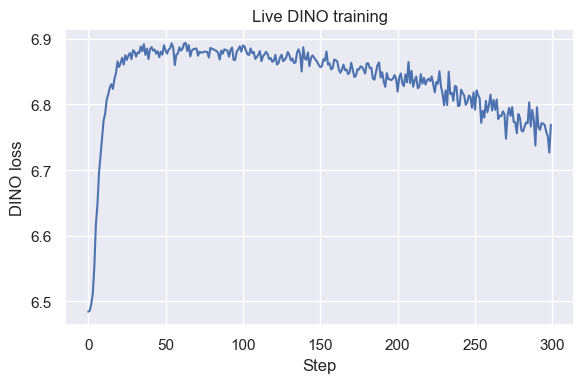

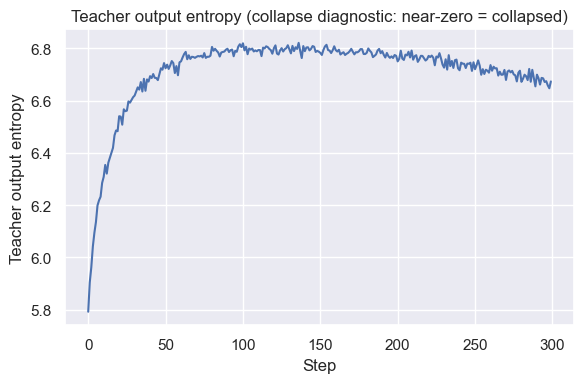

In [7]:
NUM_STEPS = 300
EMA_MOMENTUM = 0.996
CENTER_MOMENTUM = 0.9
TAU_STUDENT = 0.1
TAU_TEACHER = 0.04

optimizer = optim.AdamW(student.parameters(), lr=5e-4, weight_decay=1e-4)

loss_history, entropy_history = [], []
data_iter = iter(train_loader)
student.train(); teacher.eval()

for step in tqdm(range(NUM_STEPS)):
    try:
        crops = next(data_iter)
    except StopIteration:
        data_iter = iter(train_loader)
        crops = next(data_iter)
    crops = [c.to(device) for c in crops]  # list of (B, 128, 1)

    student_logits = [student(c) for c in crops]
    with torch.no_grad():
        teacher_logits = [teacher(c) for c in crops[:2]]  # teacher sees global crops only

    loss = dino_loss(student_logits, teacher_logits, center, TAU_STUDENT, TAU_TEACHER)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    ema_update(student, teacher, m=EMA_MOMENTUM)
    center = update_center(center, teacher_logits, momentum=CENTER_MOMENTUM)

    with torch.no_grad():
        tp = F.softmax((teacher_logits[0] - center) / TAU_TEACHER, dim=-1)
        entropy = -(tp * tp.clamp_min(1e-8).log()).sum(dim=-1).mean()
    loss_history.append(loss.item())
    entropy_history.append(entropy.item())

print(f"DINO loss {loss_history[0]:.3f} -> {loss_history[-1]:.3f}")
print(f"teacher entropy {entropy_history[0]:.3f} -> {entropy_history[-1]:.3f} "
      f"(0 would mean total collapse; ln({out_dim}) = {np.log(out_dim):.2f} is uniform)")

plot_curve(loss_history, xlabel="Step", ylabel="DINO loss", title="Live DINO training")
plot_curve(entropy_history, xlabel="Step", ylabel="Teacher output entropy",
           title="Teacher output entropy (collapse diagnostic: near-zero = collapsed)")

<div class="alert alert-info">

**Optional experiment.** Re-run the loop with centering effectively removed (keep `center` at
zero and never call `update_center`). The teacher entropy decays much faster toward zero -- the
model finds the trivial shortcut of mapping every series to the same output, because without
centering nothing penalizes it.

</div>

## Loading the pretrained encoder

The offline script exports the **teacher** encoder: being an EMA of the student's whole
trajectory, it is the more stable of the two representations.

In [8]:
pretrained_dino = DINOTSModel(build_ts_encoder()).to(device)
found = try_load_checkpoint(pretrained_dino.encoder, CHECKPOINT_PATH,
                            "dino_ts_encoder.pt", device)
if not found:
    print("Falling back to the briefly-trained teacher from the live-training cell above.")
    pretrained_dino = teacher

pretrained_dino.eval()
dino_encoder = pretrained_dino.encoder
for p in dino_encoder.parameters():
    p.requires_grad = False

Found pretrained model at ../../artifacts/time_series/checkpoints\dino_ts_encoder.pt, loading...


## Does it classify? The frozen linear probe

Same probe, same protocol. DINO trains the `[CLS]` token directly (the head reads it), so
`pool="cls"` is the right readout here -- as it was for contrastive, and unlike MAE.

In [9]:
train_ds = UCRDataset(DATA_PATH, TARGET_DATASET, "train")
test_ds  = UCRDataset(DATA_PATH, TARGET_DATASET, "test")
class_names = ucr_class_names(DATA_PATH, TARGET_DATASET)

tr_f, tr_y = extract_features(dino_encoder, train_ds, device, pool="cls")
te_f, te_y = extract_features(dino_encoder, test_ds,  device, pool="cls")
dino_acc = linear_probe_accuracy(tr_f, tr_y, te_f, te_y)
print(f"DINO frozen linear probe on {TARGET_DATASET}: {dino_acc:.4f}")

DINO frozen linear probe on SwedishLeaf: 0.9360


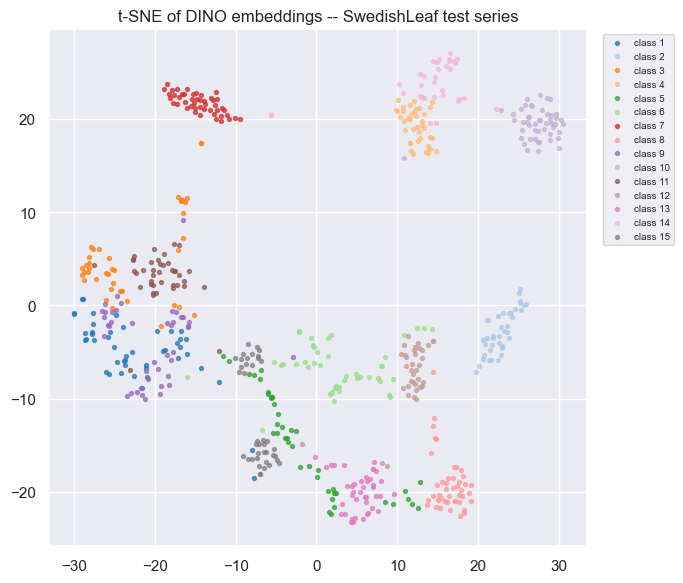

In [10]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, init="pca", perplexity=30)
embedding_2d = tsne.fit_transform(te_f)
plot_embedding_scatter(embedding_2d, te_y, class_names=class_names,
                       title=f"t-SNE of DINO embeddings -- {TARGET_DATASET} test series")

## The DINO signature visual: patch self-attention over the series

DINO's most famous result is that attention maps become interpretable **without any supervision
asking them to**. In images the `[CLS]` attention segments the foreground object. Here we plot
`[CLS]` -> patch attention over the series and shade each patch by how much the summary token
attends to it.

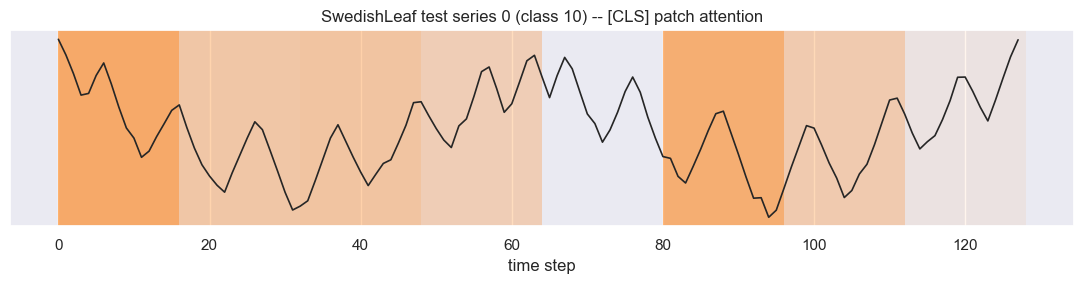

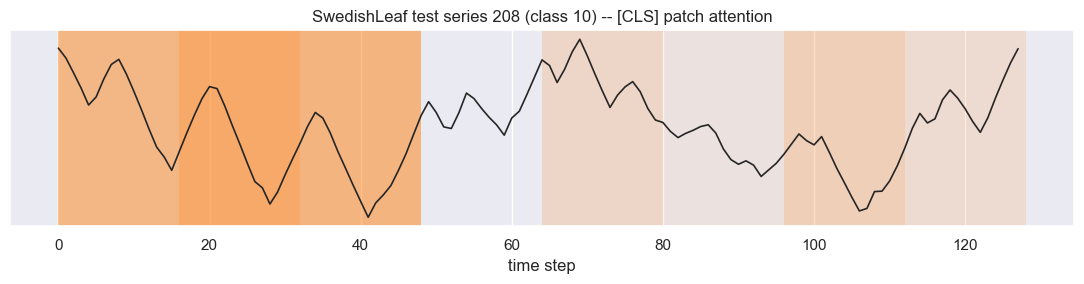

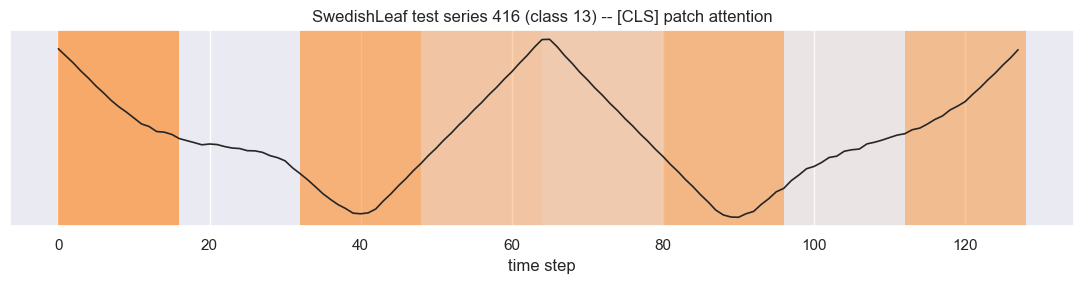

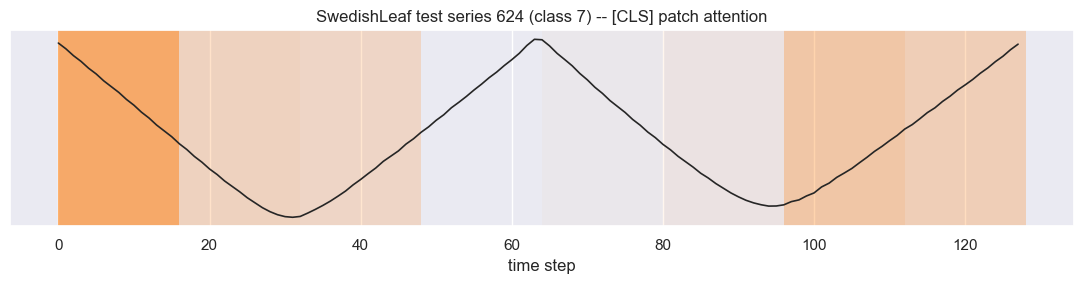

In [11]:
eval_ds = UCRDataset(DATA_PATH, TARGET_DATASET, "test")

sample_idxs = np.linspace(0, len(eval_ds) - 1, 4).astype(int)
for idx in sample_idxs:
    series, label = eval_ds[idx]
    x = series.unsqueeze(0).to(device)                 # (1, 128, 1)
    with torch.no_grad():
        _, attn = dino_encoder(x, return_attn=True)    # (1, heads, 1+P, 1+P)
    cls_attn = attn[0, :, 0, 1:].mean(dim=0)           # avg over heads, CLS -> patches
    cls_attn = (cls_attn - cls_attn.min()) / (cls_attn.max() - cls_attn.min() + 1e-8)
    overlay_attention_1d(series[:, 0].cpu(), cls_attn.cpu().numpy(),
                         PATCH_LEN, PATCH_STRIDE,
                         title=f"{TARGET_DATASET} test series {idx} ({class_names[label]}) "
                               f"-- [CLS] patch attention")

**Reading the attention.** Look for whether high attention lands on structurally
distinctive spans -- the deep notches between lobes, sharp turning points, the most
irregular stretch of the trace -- rather than spreading uniformly. Nothing in the DINO loss asks
for this. It emerges because the `[CLS]` token must summarize "what makes this series match the
other views of itself", and the answer is its distinctive shape.

Contrast with Notebook 1: there is **no repulsion term** anywhere in DINO. Everything the model
learns comes from matching views of the *same* series, mediated by the slow EMA teacher and kept
off the collapse solution by centering and sharpening. Three quite different mechanisms --
push-and-pull, reconstruct-the-hidden, match-your-own-average -- and Notebook 4 now asks which
of them produced the most useful representation.

### References

- Caron, M. et al. (2021). *Emerging Properties in Self-Supervised Vision Transformers
  (DINO).* ICCV.
- Oquab, M. et al. (2023). *DINOv2: Learning Robust Visual Features without Supervision.*
  arXiv:2304.07193.
- Fraikin, A. et al. (2023). *T-Rep: Representation Learning for Time Series using
  Time-Embeddings.*
- Nie, Y. et al. (2023). *PatchTST.* ICLR.